Load the CSV

In [1]:
import pandas as pd

report_df = pd.read_csv("clinical_reporting_research_code_candidates.csv")

report_df.head()

,note_id,note_date,source,concept,code_system,candidate_code,description,snomed_ct_candidate,reporting_category,research_category,confidence,review_decision,evidence_found_in_note,validation_reason
0,1,2024-01-15,rule_based_mapping,type_2_diabetes,ICD-10-CM,E11.9,Type 2 diabetes mellitus without complications,Type 2 diabetes mellitus,chronic_condition,diabetes_cohort,rule_match,human_review_recommended,True,Evidence found in note.
1,1,2024-01-15,rule_based_mapping,medication_reconciliation,Workflow,MED_RECON_REVIEW,Medication reconciliation review needed,Medication review,care_management,medication_management,rule_match,human_review_required,False,Evidence not found exactly. Human review requi...
2,1,2024-01-15,rule_based_mapping,follow_up_needed,Workflow,FOLLOW_UP_NEEDED,Follow-up visit or monitoring planned,Follow-up encounter,care_plan,follow_up_tracking,rule_match,human_review_recommended,True,Evidence found in note.
3,1,2024-01-15,clinicalbert_similarity,medication_reconciliation,Workflow,MED_RECON_REVIEW,Medication reconciliation review needed,Medication review,care_management,medication_management,medium,human_review_required,False,ClinicalBERT semantic match. Exact evidence ne...
4,1,2024-01-15,clinicalbert_similarity,follow_up_needed,Workflow,FOLLOW_UP_NEEDED,Follow-up visit or monitoring planned,Follow-up encounter,care_plan,follow_up_tracking,medium,human_review_required,False,ClinicalBERT semantic match. Exact evidence ne...


Our Goal is -structured clinical data → report table

Check the columns

In [2]:
report_df.columns

Index(['note_id', 'note_date', 'source', 'concept', 'code_system',
       'candidate_code', 'description', 'snomed_ct_candidate',
       'reporting_category', 'research_category', 'confidence',
       'review_decision', 'evidence_found_in_note', 'validation_reason'],
      dtype='object')

Basic dashboard summary numbers

In [3]:
total_rows = len(report_df)
total_notes = report_df["note_id"].nunique()
total_concepts = report_df["concept"].nunique()
total_review_needed = len(report_df[report_df["review_decision"] != "review_optional_for_demo"])

print("CLINICAL REPORTING DASHBOARD")
print("=" * 50)

print("Total code candidates:", total_rows)
print("Total clinical notes:", total_notes)
print("Unique clinical concepts:", total_concepts)
print("Items needing human review:", total_review_needed)

CLINICAL REPORTING DASHBOARD
Total code candidates: 26
Total clinical notes: 3
Unique clinical concepts: 8
Items needing human review: 26


Count by code system

In [4]:
code_system_report = report_df["code_system"].value_counts().reset_index()

code_system_report.columns = ["code_system", "count"]

code_system_report

,code_system,count
0,ICD-10-CM,11
1,Workflow,11
2,CPT,4


Count by concept

In [5]:
concept_report = report_df["concept"].value_counts().reset_index()

concept_report.columns = ["concept", "count"]

concept_report

,concept,count
0,medication_reconciliation,6
1,follow_up_needed,5
2,ekg_service,4
3,shortness_of_breath,4
4,abnormal_ekg,3
5,chest_pain,2
6,type_2_diabetes,1
7,hypertension,1


Count by reporting category

In [11]:
reporting_category_report = report_df["reporting_category"].value_counts().reset_index()

reporting_category_report.columns = ["reporting_category", "count"]

reporting_category_report

,reporting_category,count
0,care_management,6
1,symptom,6
2,care_plan,5
3,procedure_or_test,4
4,diagnostic_finding,3
5,chronic_condition,2


Count by research category

In [6]:
research_category_report = report_df["research_category"].value_counts().reset_index()

research_category_report.columns = ["research_category", "count"]

research_category_report

,research_category,count
0,medication_management,6
1,follow_up_tracking,5
2,diagnostic_testing,4
3,respiratory_symptom_cohort,4
4,cardiac_testing_cohort,3
5,cardiac_symptom_cohort,2
6,diabetes_cohort,1
7,hypertension_cohort,1


Human review report

In [7]:
review_report = report_df["review_decision"].value_counts().reset_index()

review_report.columns = ["review_decision", "count"]

review_report

,review_decision,count
0,human_review_required,20
1,human_review_recommended,6


Evidence validation report

In [8]:
evidence_report = report_df["evidence_found_in_note"].value_counts().reset_index()

evidence_report.columns = ["evidence_found_in_note", "count"]

evidence_report

,evidence_found_in_note,count
0,False,20
1,True,6


False = needs human review
True = evidence directly found in note

Simple bar chart: code systems

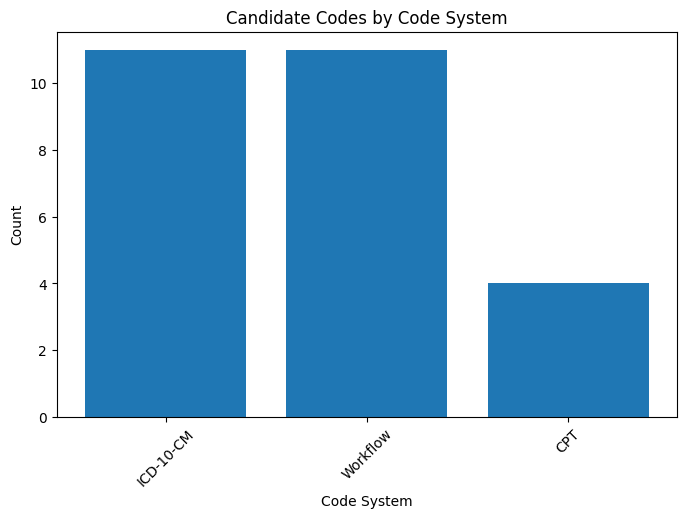

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(code_system_report["code_system"], code_system_report["count"])
plt.title("Candidate Codes by Code System")
plt.xlabel("Code System")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Simple bar chart: reporting categories

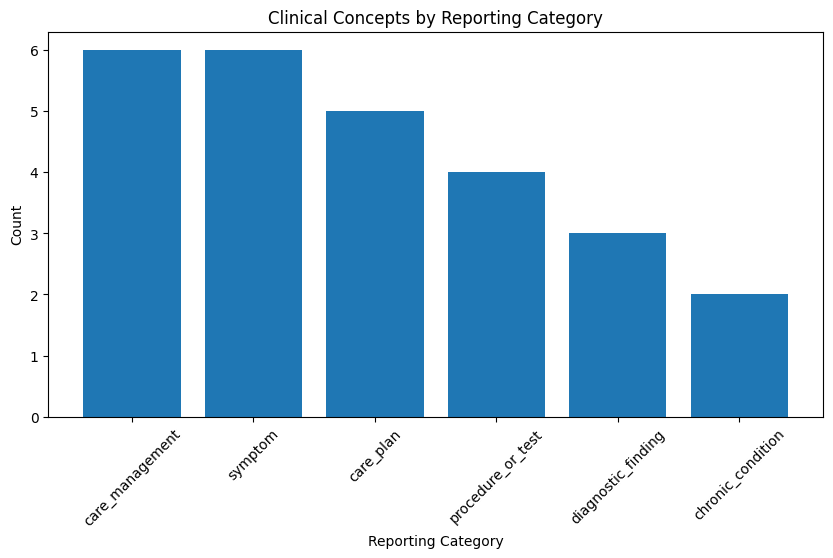

In [12]:
plt.figure(figsize=(10, 5))
plt.bar(reporting_category_report["reporting_category"], reporting_category_report["count"])
plt.title("Clinical Concepts by Reporting Category")
plt.xlabel("Reporting Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Simple bar chart: research categories

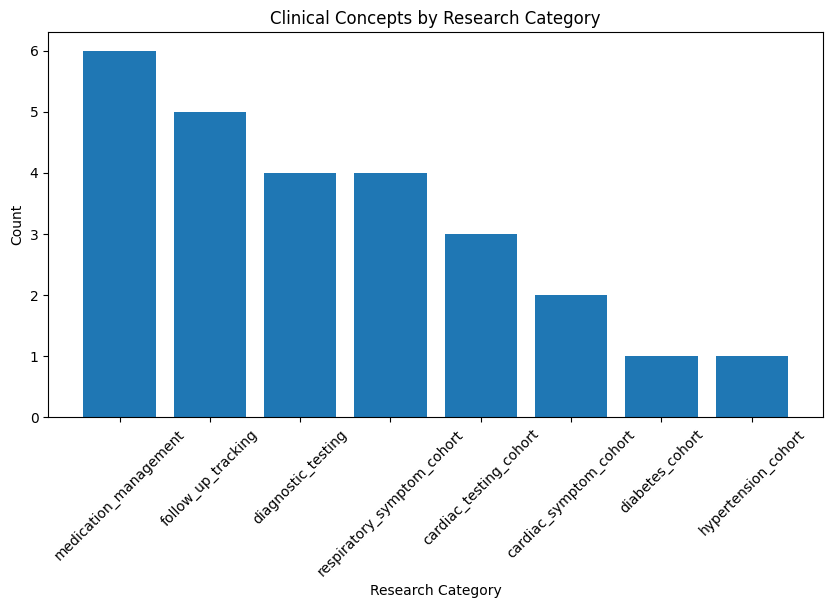

In [14]:
plt.figure(figsize=(10, 5))
plt.bar(research_category_report["research_category"], research_category_report["count"])
plt.title("Clinical Concepts by Research Category")
plt.xlabel("Research Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Simple bar chart: human review status

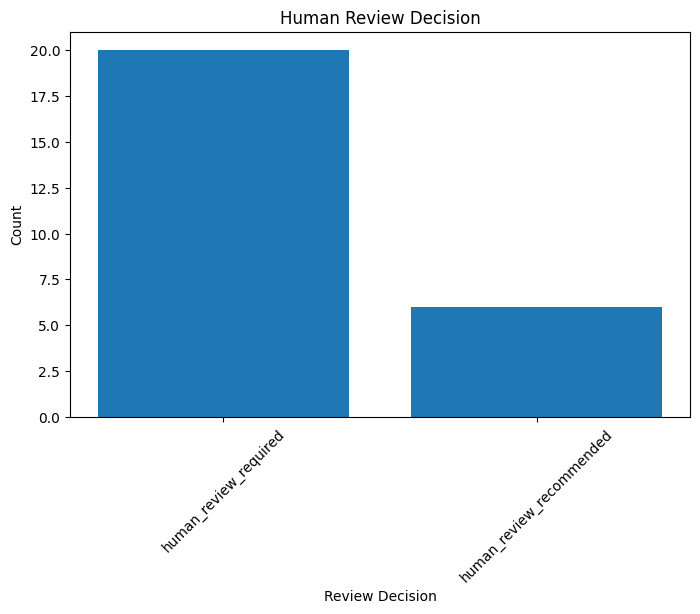

In [15]:
plt.figure(figsize=(8, 5))
plt.bar(review_report["review_decision"], review_report["count"])
plt.title("Human Review Decision")
plt.xlabel("Review Decision")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Create a note-level dashboard table

In [16]:
note_level_report = report_df.groupby("note_id").agg(
    total_candidates=("candidate_code", "count"),
    unique_concepts=("concept", "nunique"),
    review_needed=("review_decision", lambda x: sum(x != "review_optional_for_demo")),
    evidence_found=("evidence_found_in_note", lambda x: sum(x == True))
).reset_index()

note_level_report

,note_id,total_candidates,unique_concepts,review_needed,evidence_found
0,1,8,6,8,2
1,2,8,6,8,1
2,3,10,6,10,3


For each note:
How many candidate codes?
How many concepts?
How many need review?
How many have evidence?

Save dashboard summary tables

In [17]:
code_system_report.to_csv("dashboard_code_system_report.csv", index=False)
concept_report.to_csv("dashboard_concept_report.csv", index=False)
reporting_category_report.to_csv("dashboard_reporting_category_report.csv", index=False)
research_category_report.to_csv("dashboard_research_category_report.csv", index=False)
review_report.to_csv("dashboard_review_report.csv", index=False)
note_level_report.to_csv("dashboard_note_level_report.csv", index=False)

print("Dashboard summary CSV files saved.")

Dashboard summary CSV files saved.


Create a simple HTML report

In [18]:
html_report = f"""
<html>
<head>
    <title>Clinical Reporting Dashboard</title>
</head>
<body>
    <h1>Clinical Reporting and Research Dashboard</h1>

    <h2>Summary</h2>
    <p><b>Total code candidates:</b> {total_rows}</p>
    <p><b>Total clinical notes:</b> {total_notes}</p>
    <p><b>Unique clinical concepts:</b> {total_concepts}</p>
    <p><b>Items needing human review:</b> {total_review_needed}</p>

    <h2>Code System Report</h2>
    {code_system_report.to_html(index=False)}

    <h2>Concept Report</h2>
    {concept_report.to_html(index=False)}

    <h2>Reporting Category Report</h2>
    {reporting_category_report.to_html(index=False)}

    <h2>Research Category Report</h2>
    {research_category_report.to_html(index=False)}

    <h2>Human Review Report</h2>
    {review_report.to_html(index=False)}

    <h2>Evidence Validation Report</h2>
    {evidence_report.to_html(index=False)}

    <h2>Note Level Report</h2>
    {note_level_report.to_html(index=False)}

    <h2>Safety Note</h2>
    <p>This dashboard is for educational reporting and research demonstration only.
    It is not final billing, diagnosis, or treatment advice. Human review is required.</p>
</body>
</html>
"""

with open("clinical_reporting_dashboard.html", "w") as file:
    file.write(html_report)

print("HTML dashboard saved: clinical_reporting_dashboard.html")

HTML dashboard saved: clinical_reporting_dashboard.html


In [19]:
from IPython.display import HTML

with open('clinical_reporting_dashboard.html', 'r') as f:
    html_content = f.read()

HTML(html_content)

code_system,count
ICD-10-CM,11
Workflow,11
CPT,4
concept,count
medication_reconciliation,6
follow_up_needed,5
ekg_service,4
shortness_of_breath,4
abnormal_ekg,3
chest_pain,2
